In [2]:
'''
Import libraries
'''
import numpy as np
from scipy.sparse import linalg

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

In [3]:
'''
Initializations
'''
# Create a list of 17 bond lengths for the Hydrogen molecule
bond_lengths = np.array([1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])/2

# Calculate the mean ground energies in the Kolos et al. paper
enery_Kolos_upper = np.array([-1.12453881, -1.16493435, - 1.17234623, -1.17445199, -1.17447477, -1.17447498, -1.17446041 , -1.17285408, -1.16858212, -1.15506752, -1.13813155, -1.12013035, -1.10242011, -1.08578740, -1.07067758, -1.05731738, -1.04578647])

enery_Kolos_lower = np.array([-1.12453864, -1.16493411, -1.17234596, -1.17445199, -1.17447477, -1.17447466, -1.17446041 , -1.17285370, -1.16858164, -1.15506694, - 1.13813078, -1.12012903, -1.10241799, -1.08578400, -1.07067254, -1.05730948, -1.04577476])

enery_Kolos_mean = enery_Kolos_upper + enery_Kolos_lower
enery_Kolos_mean = enery_Kolos_mean/2

# Create an empty array to store the ground state energies
# simulated at different bond lengths
energy = []

In [4]:
'''
Simulate the ground state energy of the Hydrogen molecule at each bond length
'''
for bond_length in bond_lengths:

	# Set molecule parameters
	geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, bond_length))]
	basis = 'sto-3g'
	multiplicity = 1
	charge = 0

	# Perform electronic structure calculations and
	# obtain Hamiltonian as an InteractionOperator
	hamiltonian = ofpyscf.generate_molecular_hamiltonian(geometry, basis, multiplicity, charge)
	# Convert to a FermionOperator
	hamiltonian_ferm_op = of.get_fermion_operator(hamiltonian)

	# Map to QubitOperator using the JWT
	hamiltonian_bk = of.bravyi_kitaev(hamiltonian_ferm_op)

	# Convert to Scipy sparse matrix
	hamiltonian_bk_sparse = of.get_sparse_operator(hamiltonian_bk)

	# Compute ground energy
	eigs, _ = linalg.eigsh(hamiltonian_bk_sparse, k=1, which='SA')
	ground_energy = eigs[0]

	# Store the ground state energy at each bond length in the energy array
	if bond_length == bond_lengths[0]:
		energy = np.array(ground_energy)
	else:
		energy = np.append(energy, ground_energy)

In [5]:
'''
Quantitative analysis
'''
# The average absolute difference between two energy curves
abs_diff = np.average(np.abs(energy - enery_Kolos_mean))
print("The absolute error between the two ground energy "
	  "dataset is {0:0.8f} Hartrees.\n".format(abs_diff))

# The average absolute relative differnce between two energy curves
rel_diff = np.average(np.abs(np.divide((energy - enery_Kolos_mean), enery_Kolos_mean)))
print("The absolute relative error between the two ground "
	  "energy dataset is {0:0.2f}%.\n\n".format(rel_diff*100))

# The bond length corresponding to the lowest ground state enery in this study
bond_lengths_min = bond_lengths[np.argmin(energy)]
print("The bond length corresponding to the lowest ground state "
	  "enery in this study is {0:0.3f} angstrom \n.".format(bond_lengths_min))
# The mimimum energy
print("The minimum ground state energy in this study is "
	  "{0:0.8f} Hartrees.\n\n".format(np.amin(energy)))

# The bond length corresponding to the lowest ground state enery in Kolos et al. study
bond_lengths_min_Kolos = bond_lengths[np.argmin(enery_Kolos_mean)]
print("The bond length corresponding to the lowest ground state "
	  "enery in Kolos et al. study is {0:0.3f} angstrom \n.".format(bond_lengths_min_Kolos))
# The mimimum energy
print("The minimum ground state energy in Kolos et al. study is "
	  "{0:0.8f} Hartrees.\n\n".format(np.amin(enery_Kolos_mean)))

The absolute error between the two ground energy dataset is 0.04524362 Hartrees.

The absolute relative error between the two ground energy dataset is 4.02%.


The bond length corresponding to the lowest ground state enery in this study is 0.750 angstrom 
.
The minimum ground state energy in this study is -1.13711707 Hartrees.


The bond length corresponding to the lowest ground state enery in Kolos et al. study is 0.701 angstrom 
.
The minimum ground state energy in Kolos et al. study is -1.17447482 Hartrees.




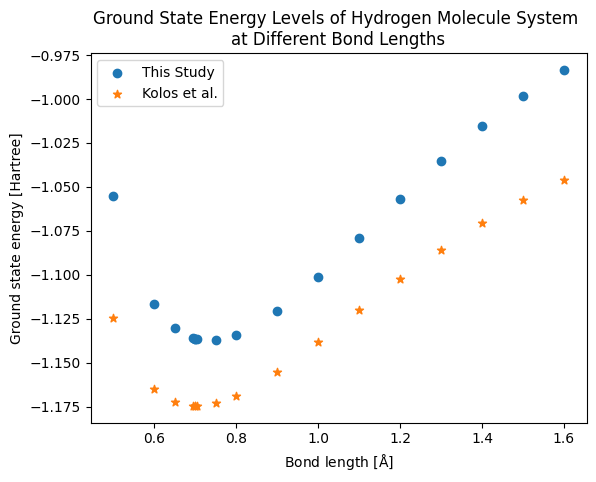

In [7]:
'''
Generate the plot of ground state energy of the Hydrogen molecule
as the function of the 17 bond lengths
'''
# Plot the energy curve from this study
plt.scatter(bond_lengths, energy, marker = "o", label = "This Study")

# Plot the energy curve with the data from Kolos et al. paper
plt.scatter(bond_lengths, enery_Kolos_mean, marker = "*", label = "Kolos et al.")

# Add labels, title and legend on the plot
plt.xlabel('Bond length [$\mathrm{\AA}$]')
plt.ylabel('Ground state energy [Hartree]')
plt.title('Ground State Energy Levels of Hydrogen Molecule System \nat Different Bond Lengths')
plt.legend()

# Save an show the plot
plt.savefig('groundEnergy.png')
plt.show()